# # 05 — Baseline Forecast & Incremental Sales (MVP 02)
#
# **Pipeline stage: model-based counterfactual for promotion evaluation.**
#
# MVP 01 gave us the *descriptive* before/during/after view. This notebook replaces the
# pre-window average with a **LightGBM baseline forecast**: what would sales have been
# **without** the promotion?
#
# ```
# product-day feature grid (calendar + lags + rolling + promotion-aware features)
#   -> LightGBM quantity model + LightGBM revenue model
#   -> time-based validation (12-week holdout with a purge gap)
#   -> SHAP explanations
#   -> counterfactual: re-predict with promotion features zeroed
#   -> incremental sales / revenue / uplift % / confidence per campaign x product
#   -> model_*.pkl | baseline_predictions.parquet | incremental_*.parquet | shap
# ```
#
# Key design choices:
# - **Dense product-day grid** so lags / rolling features are well-defined on zero-sale days.
# - **Forecast universe** = top promoted products by lifetime sales (MVP scope, ~800 SKUs).
# - **Promotion-aware features** (discount depth, display/mailer share, campaign flag) let the
#   model learn promotion effects; the counterfactual zeroes them out.
# - **Known limitation (documented)**: lag/rolling features are observed values, so the
#   counterfactual still contains partial promotion carry-over. A structural / simulated
#   counterfactual is the stated future improvement.


In [1]:
# --- environment --------------------------------------------------------------
import sys
import json
import warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")

def _find_root() -> Path:
    p = Path.cwd()
    for q in [p, *p.parents]:
        if (q / "data" / "raw" / "transaction_data.csv").exists():
            return q
    return p

ROOT = _find_root()
sys.path.insert(0, str(ROOT / "notebooks"))

from utils import data as UD
from utils import features as UF
from utils import common as UC

logger = UC.setup_logging("baseline_forecast")


@dataclass(frozen=True)
class Config:
    """Single source of truth for MVP 02."""
    seed: int = 42
    n_jobs: int = 8
    universe_size: int = 800               # top promoted products by lifetime sales
    validation_weeks: int = 12             # holdout at the end of the time series
    purge_days: int = 14                   # gap between train and validation (no leakage)
    lags: tuple = (1, 2, 3, 7, 14, 28)
    roll_windows: tuple = (7, 14, 28)
    lgb_params: dict = None
    n_estimators: int = 1000
    early_stopping: int = 75
    shap_sample: int = 3000                # rows for SHAP analysis
    z_conf: float = 1.96                   # 95% CI
    min_res_days: int = 7                  # per-product residual days required for local CI
    output_dir: Path = UC.pipeline_dir("baseline_forecast")
    figures_dir: Path = UC.figures_dir("baseline_forecast")

    def __post_init__(self):
        if self.lgb_params is None:
            object.__setattr__(self, "lgb_params", {
                "objective": "regression", "metric": "rmse",
                "learning_rate": 0.05, "num_leaves": 63,
                "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 1,
                "min_data_in_leaf": 100, "n_jobs": self.n_jobs,
                "seed": self.seed, "verbosity": -1,
            })


CFG = Config()
UC.set_seed(CFG.seed)
print(f"Output dir  : {CFG.output_dir}")


Output dir  : /home/mhseddighi/Projects/promotion-intelligence/outputs/baseline_forecast


# ## 1. Data Loading
#
# Reuses the typed loaders and the cached product-week display/mailer calendar from MVP 01.
# Product-level static features come from the Product Intelligence pipeline
# (`outputs/product_intelligence/product_features.parquet`) — embeddings and relationship
# outputs are consumed by MVP 04.


In [2]:
tx = UD.load_transactions_fast()
products = UD.load_products()
campaign_desc = UD.campaign_days(UD.load_campaign_desc())
causal_weekly = UD.load_or_build_causal_weekly(logger=logger)
promoted = pd.read_parquet(UC.OUTPUTS_ROOT / "promotion_analysis" / "promoted_products.parquet")

MAX_DAY = int(tx["DAY"].max())
VALID_START = MAX_DAY - CFG.validation_weeks * 7 + 1
TRAIN_END = VALID_START - CFG.purge_days

pi_features_path = UC.OUTPUTS_ROOT / "product_intelligence" / "product_features.parquet"
product_features = (pd.read_parquet(pi_features_path)
                    if pi_features_path.exists() else None)

print(f"transactions    : {tx.shape}")
print(f"campaigns       : {len(campaign_desc)}")
print(f"causal_weekly   : {causal_weekly.shape}")
print(f"promoted        : {promoted.shape}")
print(f"MAX_DAY         : {MAX_DAY} | valid start: {VALID_START} | train end: {TRAIN_END}")
print(f"PI features     : {'loaded' if product_features is not None else 'NOT FOUND (fallback to raw)'}")


22:40:44 | INFO    | baseline_forecast | Loading cached causal_weekly from /home/mhseddighi/Projects/promotion-intelligence/data/processed/causal_weekly.parquet


transactions    : (2595732, 12)
campaigns       : 30
causal_weekly   : (2049187, 4)
promoted        : (404361, 12)
MAX_DAY         : 711 | valid start: 628 | train end: 614
PI features     : loaded


In [3]:
def validate_loading() -> None:
    assert tx.shape[0] > 1_000_000
    assert promoted["CAMPAIGN"].nunique() >= 30
    assert causal_weekly.shape[0] > 1_000_000
    assert VALID_START > TRAIN_END > 0
    UC.check_no_nan_inf(causal_weekly, context="causal_weekly")
    print("PASS: loading validated")


validate_loading()


PASS [nan/inf] causal_weekly: no NaN/Inf in 2,049,187 rows
PASS: loading validated


# ## 2. Forecast Universe
#
# The dense product-day grid over all ~48k promoted products would be 34M rows — out of
# scope for an MVP. We select the **top promoted products by lifetime sales** and report
# how much of the promoted-period sales value the universe covers.


In [4]:
prod_totals = tx.groupby("PRODUCT_ID")["SALES_VALUE"].sum().rename("total_sales").reset_index()
promoted_ids = set(promoted["PRODUCT_ID"].unique())
universe = (prod_totals[prod_totals["PRODUCT_ID"].isin(promoted_ids)]
            .nlargest(CFG.universe_size, "total_sales")[["PRODUCT_ID", "total_sales"]])

coverage = (promoted[promoted["PRODUCT_ID"].isin(universe["PRODUCT_ID"])]["promo_sales"].sum()
            / promoted["promo_sales"].sum() * 100.0)
print(f"Universe size          : {len(universe):,} products")
print(f"Promo-sales coverage   : {coverage:.1f}% of all promoted-period sales value")
print(f"Grid rows (dense)      : {len(universe) * MAX_DAY:,}")


Universe size          : 800 products
Promo-sales coverage   : 44.1% of all promoted-period sales value
Grid rows (dense)      : 568,800


In [5]:
def validate_universe() -> None:
    assert len(universe) == CFG.universe_size, "universe size mismatch"
    assert universe["PRODUCT_ID"].is_unique
    assert (universe["total_sales"] > 0).all()
    assert coverage > 10.0, "universe covers too little promoted value"
    print("PASS: universe validated")


validate_universe()


PASS: universe validated


# ## 3. Feature Engineering
#
# One dense row per (product, day) with four feature groups:
#
# - **Calendar** — day-of-week, month, quarter, week-of-year, weekend.
# - **Promotion-aware (day)** — discount flag/rate/depth, display/mailer share, campaign flag.
# - **History** — lags and rolling mean/std of quantity (shifted so no leakage).
# - **Product static** — avg price, product-level discount rate, volatility, categories.
#
# Categoricals are ordinal-encoded with an explicit unknown bucket and the encoders are
# persisted so the recommendation stage (09) can build scenario rows with the same schema.


In [6]:
grid = UF.build_dense_product_day_grid(universe["PRODUCT_ID"].to_numpy(), max_day=MAX_DAY)
grid = UF.merge_promotion_day_features(grid, tx)
grid = UF.merge_causal_week_features(grid, causal_weekly)
grid = UF.add_campaign_flags(grid, campaign_desc)
grid = UF.add_calendar_features(grid)
grid = UF.add_lag_features(grid, group_col="PRODUCT_ID", value_col="quantity", lags=list(CFG.lags))
grid = UF.add_rolling_features(grid, group_col="PRODUCT_ID", value_col="quantity",
                               windows=list(CFG.roll_windows))
if product_features is not None:
    grid = UF.add_product_static_features(grid, product_features)
grid = grid.sort_values(["PRODUCT_ID", "DAY"]).reset_index(drop=True)

# --- ordinal encoding with unknown handling (persisted for notebook 09) -----
from sklearn.preprocessing import OrdinalEncoder

CAT_COLS = ["DEPARTMENT", "COMMODITY_DESC"]
encoders = {}
for col in CAT_COLS:
    if col not in grid.columns:
        continue
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    grid[f"{col}_enc"] = enc.fit_transform(grid[[col]].astype(str)).astype("int32")
    encoders[col] = enc
joblib.dump(encoders, CFG.output_dir / "encoders.pkl")

FEATURE_COLS = [
    "day_of_week", "month", "quarter", "week_of_year", "is_weekend",
    "has_discount", "discount_rate", "total_discount", "retail_disc", "coupon_disc",
    "has_display", "has_mailer", "display_share", "mailer_share", "promo_intensity",
    "campaign_active",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28",
    "rolling_std_7", "rolling_std_14", "rolling_std_28",
    "avg_price", "product_discount_rate", "sales_frequency", "volatility",
]
FEATURE_COLS += [f"{c}_enc" for c in CAT_COLS if f"{c}_enc" in grid.columns]
FEATURE_COLS = [c for c in FEATURE_COLS if c in grid.columns]

PROMO_ZERO_COLS = [
    "has_discount", "discount_rate", "total_discount", "retail_disc", "coupon_disc",
    "has_display", "has_mailer", "display_share", "mailer_share", "promo_intensity",
    "campaign_active",
]
PROMO_ZERO_COLS = [c for c in PROMO_ZERO_COLS if c in FEATURE_COLS]

# Strict product-level promo day: price discount or display/mailer support.
# The broad campaign_active flag alone does NOT qualify (it covers entire windows).
grid["is_promo_day"] = (
    grid["has_discount"] | grid["has_display"] | grid["has_mailer"]
).astype("int8")
UC.save_json({"feature_cols": FEATURE_COLS, "promo_zero_cols": PROMO_ZERO_COLS,
              "cat_cols": CAT_COLS, "max_day": MAX_DAY, "valid_start": VALID_START,
              "train_end": TRAIN_END},
             CFG.output_dir / "feature_cols.json", logger=logger, context="feature_cols")
print(f"Features: {len(FEATURE_COLS)} | grid rows: {len(grid):,}")
print(f"Promo-day share in grid: {grid['is_promo_day'].mean() * 100:.1f}%")


22:41:10 | INFO    | baseline_forecast | [feature_cols] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/baseline_forecast/feature_cols.json


Features: 34 | grid rows: 568,800
Promo-day share in grid: 58.6%


In [7]:
def validate_features() -> None:
    expected = ["PRODUCT_ID", "DAY", "quantity", "sales_value"] + FEATURE_COLS
    UC.check_schema(grid, expected, context="feature grid")
    UC.check_no_nan_inf(grid, context="feature grid", cols=FEATURE_COLS)
    assert grid["DAY"].max() == MAX_DAY
    assert grid.groupby("PRODUCT_ID").size().nunique() == 1, "unbalanced grid"
    # no leakage: rolling features are shifted -> no current-day value
    assert "rolling_mean_7" in grid.columns
    print("PASS: feature engineering validated")


validate_features()


PASS [schema] feature grid: 47 columns OK


PASS [nan/inf] feature grid: no NaN/Inf in 568,800 rows
PASS: feature engineering validated


# ## 4. Time-Based Model Training
#
# A single temporal split (not random): the last 12 weeks are held out, with a 14-day
# purge gap between train and validation. Two LightGBM regressors are trained — one for
# **quantity**, one for **revenue** — with early stopping on validation RMSE.


In [8]:
X = grid[FEATURE_COLS]
y_qty = grid["quantity"].astype("float32")
y_rev = grid["sales_value"].astype("float32")

train_mask = grid["DAY"] < TRAIN_END
valid_mask = grid["DAY"] >= VALID_START
print(f"train rows: {train_mask.sum():,} | purge rows: {(~train_mask & ~valid_mask).sum():,} | valid rows: {valid_mask.sum():,}")

import lightgbm as lgb

Xtr, Xva = X[train_mask], X[valid_mask]
yq_tr, yq_va = y_qty[train_mask], y_qty[valid_mask]

logger.info("Training quantity model ...")
model_q = lgb.LGBMRegressor(**CFG.lgb_params, n_estimators=CFG.n_estimators)
model_q.fit(Xtr, yq_tr, eval_set=[(Xva, yq_va)],
            callbacks=[lgb.early_stopping(CFG.early_stopping, verbose=False)])

logger.info("Training revenue model ...")
yr_tr, yr_va = y_rev[train_mask], y_rev[valid_mask]
model_r = lgb.LGBMRegressor(**CFG.lgb_params, n_estimators=CFG.n_estimators)
model_r.fit(Xtr, yr_tr, eval_set=[(Xva, yr_va)],
            callbacks=[lgb.early_stopping(CFG.early_stopping, verbose=False)])

joblib.dump(model_q, CFG.output_dir / "model_quantity.pkl")
joblib.dump(model_r, CFG.output_dir / "model_revenue.pkl")
logger.info("Models saved.")


train rows: 490,400 | purge rows: 11,200 | valid rows: 67,200


22:41:13 | INFO    | baseline_forecast | Training quantity model ...


22:42:25 | INFO    | baseline_forecast | Training revenue model ...


22:43:07 | INFO    | baseline_forecast | Models saved.


In [9]:
# --- validation metrics --------------------------------------------------------
pred_q = model_q.predict(Xva)
pred_r = model_r.predict(Xva)
naive_q = grid.loc[valid_mask, "lag_1"].to_numpy().astype("float64")

val = grid[valid_mask].copy()
val["pred_q"] = pred_q
val["pred_r"] = pred_r

metrics_overall = UC.regression_metrics(yq_va.to_numpy(), pred_q, y_baseline=naive_q)
metrics_nonpromo = UC.regression_metrics(
    yq_va.to_numpy()[val["is_promo_day"] == 0],
    pred_q[val["is_promo_day"] == 0])
metrics_promo = UC.regression_metrics(
    yq_va.to_numpy()[val["is_promo_day"] == 1],
    pred_q[val["is_promo_day"] == 1])
metrics_rev = UC.regression_metrics(yr_va.to_numpy(), pred_r)
metrics = {
    "quantity_overall": metrics_overall,
    "quantity_nonpromo": metrics_nonpromo,
    "quantity_promo": metrics_promo,
    "revenue_overall": metrics_rev,
    "best_iteration": {"quantity": int(model_q.best_iteration_),
                       "revenue": int(model_r.best_iteration_)},
}
UC.save_json(metrics, CFG.output_dir / "metrics.json", logger=logger, context="metrics")

print("=== Quantity model — validation (last 12 weeks) ===")
for k, m in metrics.items():
    if isinstance(m, dict) and "rmse" in m:
        print(f"{k:>18}: {UC.format_metrics(m)}")
print(f"\nMAE improvement vs naive (lag_1): {metrics_overall['mae_improvement_vs_naive_pct']:.1f}%")
print(f"RMSE improvement vs naive (lag_1): {metrics_overall['rmse_improvement_vs_naive_pct']:.1f}%")


22:43:09 | INFO    | baseline_forecast | [metrics] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/baseline_forecast/metrics.json


=== Quantity model — validation (last 12 weeks) ===
  quantity_overall: rmse=1949.296 | mae=64.829 | mape=91.563 | smape=127.918 | r2=0.977 | n=67200.000 | mae_improvement_vs_naive_pct=67.391 | rmse_improvement_vs_naive_pct=57.925
 quantity_nonpromo: rmse=1696.603 | mae=18.214 | mape=64.159 | smape=160.337 | r2=-340138.010 | n=27026.000
    quantity_promo: rmse=2102.268 | mae=96.189 | mape=101.630 | smape=106.108 | r2=0.984 | n=40174.000
   revenue_overall: rmse=5.638 | mae=1.869 | mape=32.387 | smape=117.430 | r2=0.960 | n=67200.000

MAE improvement vs naive (lag_1): 67.4%
RMSE improvement vs naive (lag_1): 57.9%


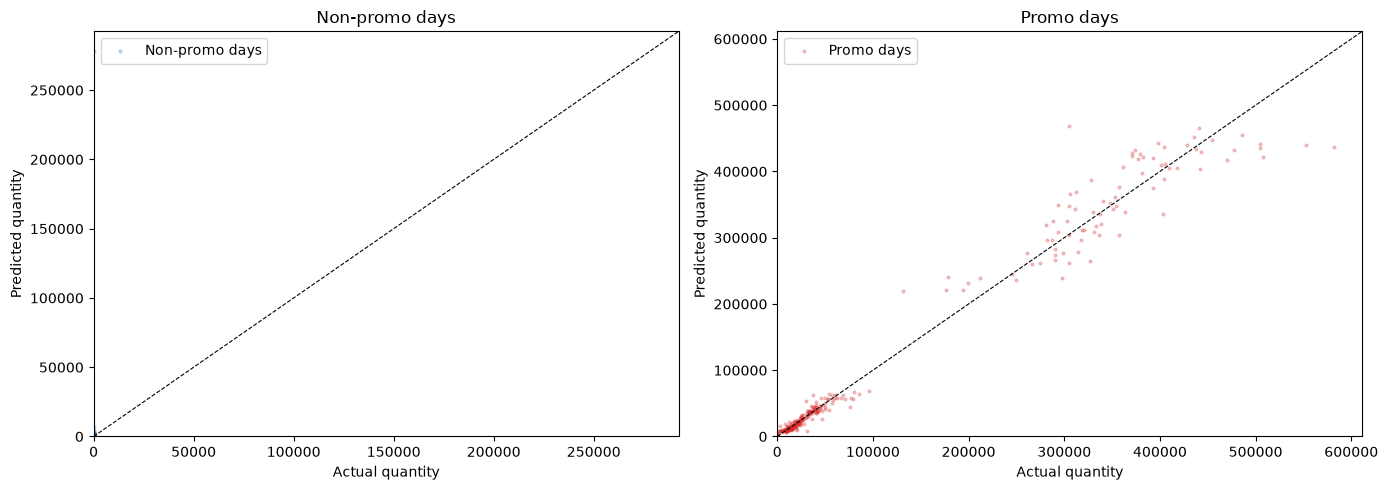

In [10]:
# Figure: validation scatter + actual-vs-predicted alignment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (mask, label, color) in zip(axes, [
        (val["is_promo_day"] == 0, "Non-promo days", "#1f77b4"),
        (val["is_promo_day"] == 1, "Promo days", "#d62728")]):
    if mask.sum() == 0:
        ax.set_title(f"{label} — no days in validation window")
        continue
    ax.scatter(val.loc[mask, "quantity"], val.loc[mask, "pred_q"], s=4, alpha=0.25,
               color=color, label=label)
    lim = [0, val.loc[mask, ["quantity", "pred_q"]].max().max() * 1.05]
    ax.plot(lim, lim, "k--", lw=0.8)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Actual quantity"); ax.set_ylabel("Predicted quantity")
    ax.set_title(label)
    ax.legend()
plt.tight_layout()
fig.savefig(CFG.figures_dir / "validation_scatter.png", dpi=110)
plt.show()


# ## 5. Feature Importance & SHAP
#
# The tree gain tells us what the model relies on globally; SHAP shows the direction and
# magnitude of each feature's effect. Both are exported for the analyst layer.


        feature         gain  split
          lag_2 1.296750e+14    461
          lag_7 1.293558e+14    528
          lag_3 6.599069e+13    540
         lag_14 6.388414e+13    538
          lag_1 6.167055e+13    613
rolling_mean_14 1.817383e+13   1195
         lag_28 1.661196e+13    537
 rolling_mean_7 1.419544e+13   1063
 total_discount 1.408946e+13   1253
    retail_disc 1.388401e+13    700
  discount_rate 2.076030e+12   1174
rolling_mean_28 1.073406e+12   1616
   has_discount 4.252133e+11    305
   week_of_year 3.562376e+11   1049
    day_of_week 2.446829e+11    374


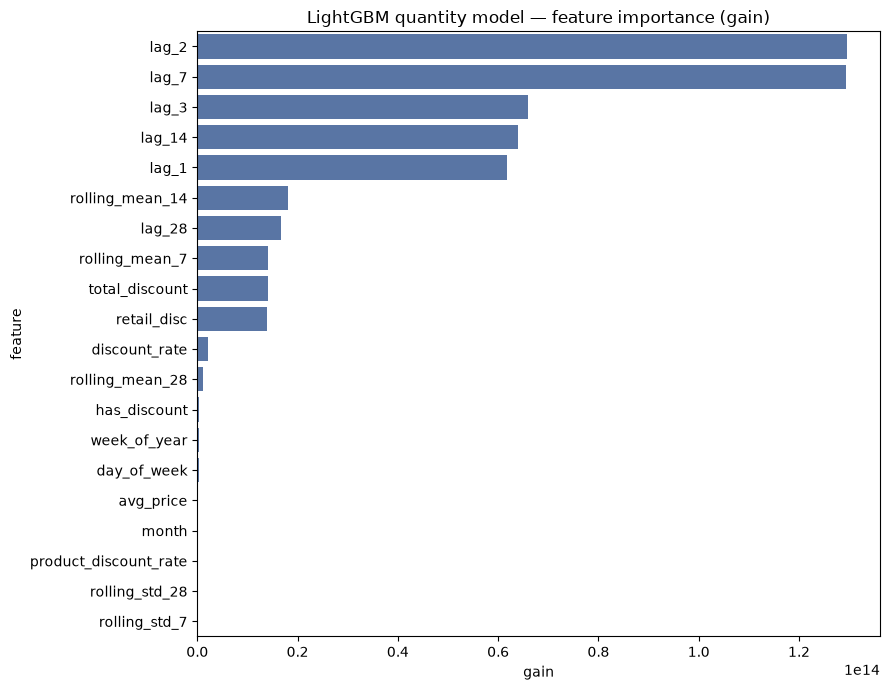

In [11]:
imp = pd.DataFrame({"feature": model_q.feature_name_,
                    "gain": model_q.booster_.feature_importance(importance_type="gain"),
                    "split": model_q.booster_.feature_importance(importance_type="split")})
imp = imp.sort_values("gain", ascending=False).reset_index(drop=True)
print(imp.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=imp.head(20), x="gain", y="feature", ax=ax, color="#4c72b0")
ax.set_title("LightGBM quantity model — feature importance (gain)")
plt.tight_layout()
fig.savefig(CFG.figures_dir / "feature_importance.png", dpi=110)
plt.show()


22:43:20 | INFO    | baseline_forecast | [shap_values] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/baseline_forecast/shap_values.parquet (3,000 rows x 36 cols)


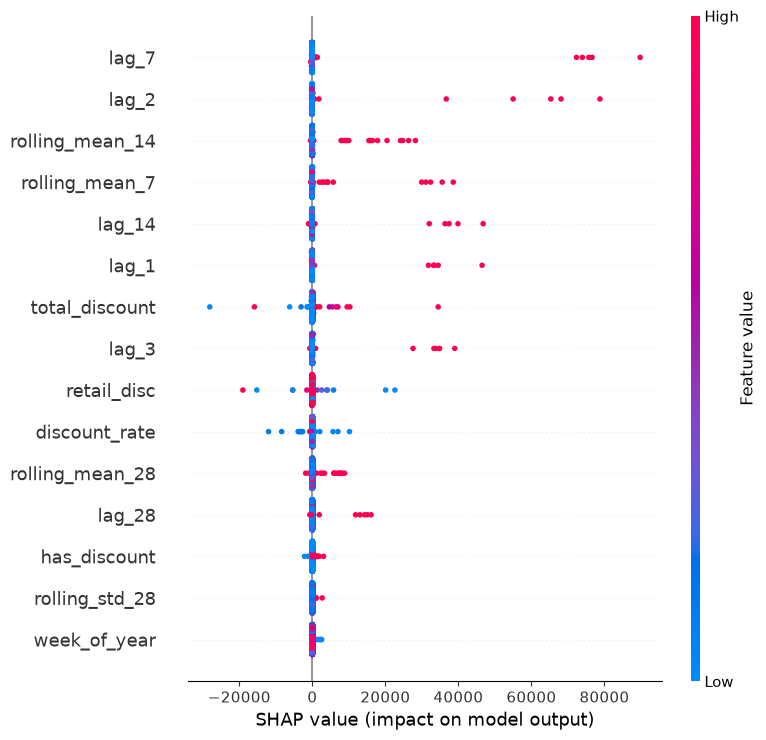

SHAP explanation saved.


In [12]:
import shap

rng = np.random.default_rng(CFG.seed)
shap_idx = rng.choice(np.where(valid_mask)[0], size=min(CFG.shap_sample, int(valid_mask.sum())),
                      replace=False)
shap_sample = grid.iloc[shap_idx][["PRODUCT_ID", "DAY"]].copy()
X_shap = X.iloc[shap_idx]
explainer = shap.TreeExplainer(model_q)
shap_values = explainer.shap_values(X_shap)

shap_df = pd.DataFrame(
    shap_values, columns=[f"shap_{c}" for c in FEATURE_COLS],
    index=shap_sample.index)
shap_out = pd.concat([shap_sample.reset_index(drop=True), shap_df.reset_index(drop=True)], axis=1)
UC.save_parquet(shap_out, CFG.output_dir / "shap_values.parquet",
                logger=logger, context="shap_values")

shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS, show=False,
                   max_display=15)
plt.tight_layout()
plt.savefig(CFG.figures_dir / "shap_summary.png", dpi=110, bbox_inches="tight")
plt.show()
print("SHAP explanation saved.")


# ### Business interpretation (SHAP)
#
# Look for three expected patterns in the summary plot:
# 1. **Lagged quantity dominates** — today's demand is the best predictor of tomorrow's.
# 2. **Promotion features move demand up** — `has_discount` / `discount_rate` push
#    predictions above baseline (positive SHAP).
# 3. **Calendar effects** — `day_of_week` and `is_weekend` capture the weekly shopping
#    rhythm; the model leans on these when no promotion is active.
#
# If promotion features barely register, the universe/features are not capturing the
# promotion signal — a useful model-health check before trusting incremental numbers.


# ## 6. Counterfactual Baseline & Incremental Sales
#
# For every (product, day) we predict twice:
#
# - **As-is prediction** — uses observed promotion features (used for validation metrics).
# - **Baseline prediction** — promotion features are zeroed: what would have sold *without*
#   the promotion, given calendar and history.
#
# Incremental sales = actual − baseline. Confidence comes from per-product residual
# standard deviation on non-promo validation days (95% CI around the summed increment).


In [13]:
logger.info("Predicting full-grid as-is and counterfactual baselines ...")
pred_all_q = model_q.predict(X)
pred_all_r = model_r.predict(X)

X_base = X.copy()
for col in PROMO_ZERO_COLS:
    X_base[col] = 0.0
base_all_q = model_q.predict(X_base)
base_all_r = model_r.predict(X_base)

preds = pd.DataFrame({
    "PRODUCT_ID": grid["PRODUCT_ID"], "DAY": grid["DAY"],
    "quantity": grid["quantity"].to_numpy(), "sales_value": grid["sales_value"].to_numpy(),
    "is_promo_day": grid["is_promo_day"].to_numpy(),
    "pred_quantity": pred_all_q, "base_quantity": base_all_q,
    "pred_revenue": pred_all_r, "base_revenue": base_all_r,
})
UC.save_parquet(preds, CFG.output_dir / "baseline_predictions.parquet",
                logger=logger, context="baseline_predictions")

# --- per-product residual std on non-promo validation days --------------------
res_q = (grid.loc[valid_mask, "quantity"].to_numpy() - pred_q)
res_r = (grid.loc[valid_mask, "sales_value"].to_numpy() - pred_r)
val_prod = grid.loc[valid_mask, "PRODUCT_ID"].to_numpy()
val_nonpromo = val["is_promo_day"].to_numpy() == 0

res_df = pd.DataFrame({"PRODUCT_ID": val_prod, "res_q": res_q, "res_r": res_r,
                       "nonpromo": val_nonpromo})
res_prod = (res_df[res_df["nonpromo"]]
            .groupby("PRODUCT_ID")[["res_q", "res_r"]]
            .agg(n=("res_q", "size"), std_q=("res_q", "std"), std_r=("res_r", "std"))
            .reset_index())
global_std_q = float(res_q[val_nonpromo].std())
global_std_r = float(res_r[val_nonpromo].std())


def merge_res_std(frame: pd.DataFrame, col: str) -> np.ndarray:
    """Per-product std with fallback to the global residual std for thin products."""
    m = frame.merge(res_prod[["PRODUCT_ID", "n", f"std_{col}"]], on="PRODUCT_ID", how="left")
    std = m[f"std_{col}"].to_numpy()
    fallback = np.where(m["n"].to_numpy() >= CFG.min_res_days, std, np.nan)
    fallback = np.where(np.isnan(fallback), globals()[f"global_std_{col}"], fallback)
    return fallback


print(f"Global residual std (qty)   : {global_std_q:.3f}")
print(f"Global residual std (revenue): {global_std_r:.3f}")
print(f"Products with local std      : {(res_prod['n'] >= CFG.min_res_days).sum()} / {len(universe)}")


22:43:25 | INFO    | baseline_forecast | Predicting full-grid as-is and counterfactual baselines ...


22:44:08 | INFO    | baseline_forecast | [baseline_predictions] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/baseline_forecast/baseline_predictions.parquet (568,800 rows x 9 cols)


Global residual std (qty)   : 1696.563
Global residual std (revenue): 5.944
Products with local std      : 489 / 800


In [14]:
# --- campaign x product incremental sales --------------------------------------
promoted_u = promoted.merge(universe[["PRODUCT_ID"]], on="PRODUCT_ID", how="inner")
promoted_u["end_eff"] = promoted_u["END_DAY"].clip(upper=MAX_DAY)
win = promoted_u[["CAMPAIGN", "PRODUCT_ID", "START_DAY", "end_eff"]].drop_duplicates()

m = preds.merge(win, on="PRODUCT_ID", how="inner")
m = m[(m["DAY"] >= m["START_DAY"]) & (m["DAY"] <= m["end_eff"])]
g = (m.groupby(["CAMPAIGN", "PRODUCT_ID"], as_index=False)
       .agg(actual_qty=("quantity", "sum"), base_qty=("base_quantity", "sum"),
            actual_rev=("sales_value", "sum"), base_rev=("base_revenue", "sum"),
            n_days=("DAY", "count"),
            start_day=("START_DAY", "first"), end_day=("end_eff", "first")))

g["incremental_qty"] = g["actual_qty"] - g["base_qty"]
g["incremental_rev"] = g["actual_rev"] - g["base_rev"]
g["uplift_qty_pct"] = np.where(g["base_qty"] > 0,
                               g["incremental_qty"] / g["base_qty"] * 100.0, 0.0)
g["uplift_rev_pct"] = np.where(g["base_rev"] > 0,
                               g["incremental_rev"] / g["base_rev"] * 100.0, 0.0)
g["std_q"] = merge_res_std(g, "q")
g["std_r"] = merge_res_std(g, "r")
for col, std in [("qty", "std_q"), ("rev", "std_r")]:
    se = g[std] * np.sqrt(g["n_days"])
    g[f"ci_low_{col}"] = g[f"incremental_{col}"] - CFG.z_conf * se
    g[f"ci_high_{col}"] = g[f"incremental_{col}"] + CFG.z_conf * se
    z = np.where(se > 0, g[f"incremental_{col}"] / se, 0.0)
    g[f"z_{col}"] = z
    g[f"confidence_{col}"] = np.clip(0.5 + 0.5 * (1 - np.exp(-np.abs(z) / 2.0)), 0.5, 0.99)

g = g.merge(products[["PRODUCT_ID", "COMMODITY_DESC", "DEPARTMENT"]],
            on="PRODUCT_ID", how="left")
UC.save_parquet(g, CFG.output_dir / "incremental_product.parquet",
                logger=logger, context="incremental_product")
print(f"Incremental rows (campaign x product): {len(g):,}")
print(g.head().to_string(index=False))


22:44:23 | INFO    | baseline_forecast | [incremental_product] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/baseline_forecast/incremental_product.parquet (19,107 rows x 25 cols)


Incremental rows (campaign x product): 19,107
 CAMPAIGN  PRODUCT_ID  actual_qty     base_qty  actual_rev  base_rev  n_days  start_day  end_day  incremental_qty  incremental_rev  uplift_qty_pct  uplift_rev_pct       std_q    std_r    ci_low_qty  ci_high_qty     z_qty  confidence_qty  ci_low_rev  ci_high_rev     z_rev  confidence_rev               COMMODITY_DESC DEPARTMENT
        1      397896     52208.0 -7319.255945  128.500000 -8.347485      38        346      383     59527.255945       136.847485        0.000000        0.000000  356.932883 0.484113  55214.703099 63839.808791 27.054375        0.990000  130.998315   142.696656 45.856258        0.990000            COUPON/MISC ITEMS  KIOSK-GAS
        1      480014     33600.0  3088.581040   82.190002 -7.380940      38        346      383     30511.418960        89.570942      987.878206        0.000000  291.411323 0.424615  26990.514081 34032.323839 16.984947        0.990000   84.440633    94.701251 34.219975        0.990000           

In [15]:
# --- campaign-level aggregation ------------------------------------------------
camp_agg = (g.groupby("CAMPAIGN", as_index=False)
              .agg(actual_qty=("actual_qty", "sum"), base_qty=("base_qty", "sum"),
                   actual_rev=("actual_rev", "sum"), base_rev=("base_rev", "sum"),
                   n_products=("PRODUCT_ID", "nunique"),
                   start_day=("start_day", "min"), end_day=("end_day", "max")))
camp_agg["incremental_qty"] = camp_agg["actual_qty"] - camp_agg["base_qty"]
camp_agg["incremental_rev"] = camp_agg["actual_rev"] - camp_agg["base_rev"]
camp_agg["uplift_qty_pct"] = np.where(camp_agg["base_qty"] > 0,
                                      camp_agg["incremental_qty"] / camp_agg["base_qty"] * 100.0, 0.0)
camp_agg["uplift_rev_pct"] = np.where(camp_agg["base_rev"] > 0,
                                      camp_agg["incremental_rev"] / camp_agg["base_rev"] * 100.0, 0.0)
# campaign-level se from per-product daily stds
se_q_c = g.groupby("CAMPAIGN").apply(
    lambda d: float(np.sqrt(np.sum((d["std_q"] ** 2) * d["n_days"]))), include_groups=False)
se_r_c = g.groupby("CAMPAIGN").apply(
    lambda d: float(np.sqrt(np.sum((d["std_r"] ** 2) * d["n_days"]))), include_groups=False)
camp_agg["se_qty"] = camp_agg["CAMPAIGN"].map(se_q_c).fillna(global_std_q)
camp_agg["se_rev"] = camp_agg["CAMPAIGN"].map(se_r_c).fillna(global_std_r)
for col, se in [("qty", "se_qty"), ("rev", "se_rev")]:
    camp_agg[f"ci_low_{col}"] = camp_agg[f"incremental_{col}"] - CFG.z_conf * camp_agg[se]
    camp_agg[f"ci_high_{col}"] = camp_agg[f"incremental_{col}"] + CFG.z_conf * camp_agg[se]
    z = np.where(camp_agg[se] > 0, camp_agg[f"incremental_{col}"] / camp_agg[se], 0.0)
    camp_agg[f"z_{col}"] = z
    camp_agg[f"confidence_{col}"] = np.clip(0.5 + 0.5 * (1 - np.exp(-np.abs(z) / 2.0)), 0.5, 0.99)

camp_agg = camp_agg.merge(campaign_desc[["CAMPAIGN", "DESCRIPTION"]], on="CAMPAIGN", how="left")
UC.save_parquet(camp_agg, CFG.output_dir / "incremental_campaign.parquet",
                logger=logger, context="incremental_campaign")
print(camp_agg[["CAMPAIGN", "DESCRIPTION", "n_products", "base_qty", "actual_qty",
                "incremental_qty", "uplift_qty_pct", "incremental_rev",
                "confidence_qty"]].round(1).sort_values("incremental_qty", ascending=False)
      .head(12).to_string(index=False))


22:44:24 | INFO    | baseline_forecast | [incremental_campaign] WROTE /home/mhseddighi/Projects/promotion-intelligence/outputs/baseline_forecast/incremental_campaign.parquet (30 rows x 23 cols)


 CAMPAIGN DESCRIPTION  n_products   base_qty  actual_qty  incremental_qty  uplift_qty_pct  incremental_rev  confidence_qty
       15       TypeC         728 43829039.6  68762142.0       24933102.4            56.9         241562.3             1.0
       20       TypeC         667 19160104.0  30044158.0       10884054.0            56.8         112170.2             1.0
       14       TypeC         688 18028792.6  28905655.0       10876862.4            60.3          92475.8             1.0
       18       TypeA         629 15191351.2  23983256.0        8791904.8            57.9          87900.6             1.0
       13       TypeA         656 13077184.2  21396512.0        8319327.8            63.6          72744.6             1.0
       11       TypeB         630 12468444.5  20676624.0        8208179.5            65.8          78679.1             1.0
        3       TypeC         691 14565371.9  22541962.0        7976590.1            54.8         103380.4             1.0
        8       

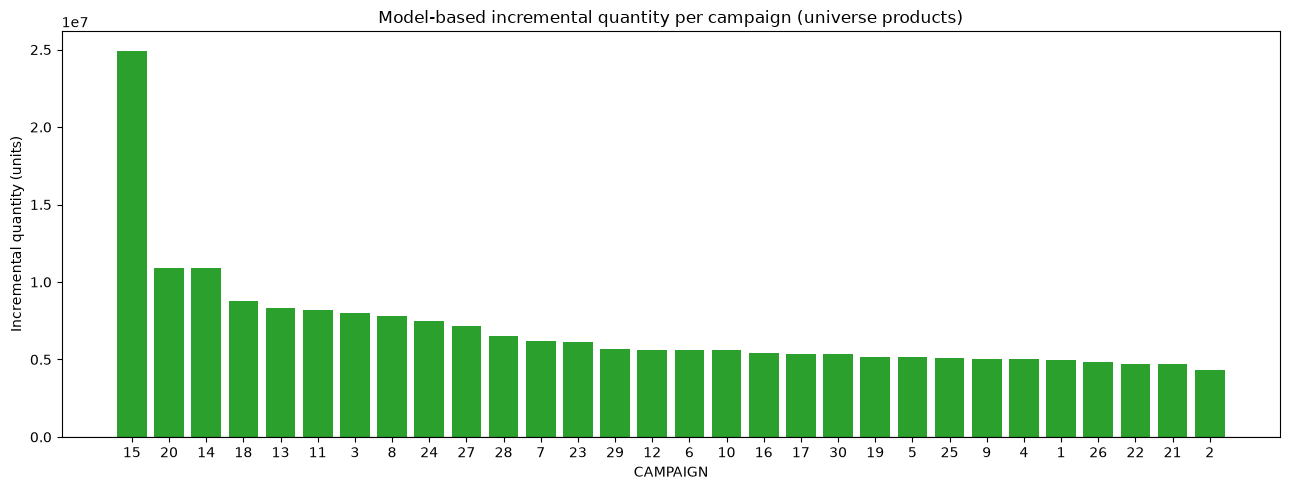

In [16]:
# Figure: incremental sales by campaign + example product forecast
fig, ax = plt.subplots(figsize=(13, 5))
order = camp_agg.sort_values("incremental_qty", ascending=False)["CAMPAIGN"]
colors = np.where(camp_agg.set_index("CAMPAIGN").loc[order, "incremental_qty"] >= 0,
                  "#2ca02c", "#d62728")
ax.bar(order.astype(str), camp_agg.set_index("CAMPAIGN").loc[order, "incremental_qty"],
       color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Model-based incremental quantity per campaign (universe products)")
ax.set_xlabel("CAMPAIGN"); ax.set_ylabel("Incremental quantity (units)")
plt.tight_layout()
fig.savefig(CFG.figures_dir / "incremental_by_campaign.png", dpi=110)
plt.show()


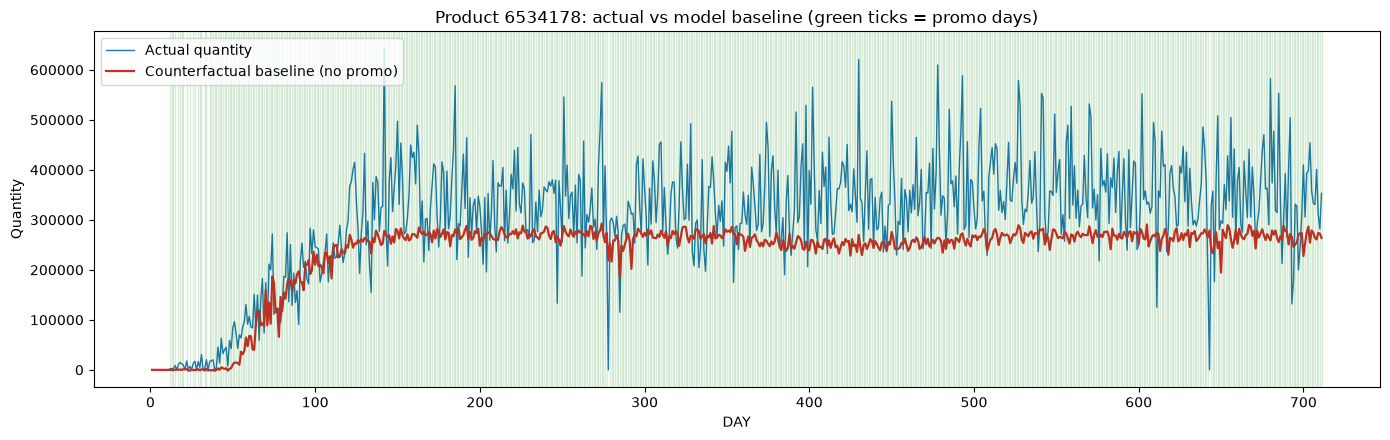

In [17]:
# Example: a top product — actual vs counterfactual baseline around its promo days
example_pid = int(universe.sort_values("total_sales", ascending=False).iloc[0]["PRODUCT_ID"])
ex = preds[preds["PRODUCT_ID"] == example_pid].sort_values("DAY")
promo_days = ex[ex["is_promo_day"] == 1]["DAY"]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(ex["DAY"], ex["quantity"], lw=1.0, color="#1f77b4", label="Actual quantity")
ax.plot(ex["DAY"], ex["base_quantity"], lw=1.6, color="#d62728", label="Counterfactual baseline (no promo)")
for d in promo_days:
    ax.axvline(d, alpha=0.15, color="green", lw=1)
ax.set_title(f"Product {example_pid}: actual vs model baseline (green ticks = promo days)")
ax.set_xlabel("DAY"); ax.set_ylabel("Quantity")
ax.legend()
plt.tight_layout()
fig.savefig(CFG.figures_dir / "example_forecast.png", dpi=110)
plt.show()


# ## 7. Prediction Examples & Business Interpretation
#
# The table below is the analyst-facing contract: for every campaign it answers
# **"how many extra units and dollars did the promotion generate vs the model baseline,
# and how confident are we?"** A negative value means the campaign under-delivered
# relative to its baseline.
#
# > **Reading the numbers**: a few bulk SKUs in the Dunnhumby data sell hundreds of
# > millions of units at fractions of a cent per unit. They dominate *unit* counts, so
# > treat **dollar-based metrics (incremental revenue) as the primary KPI** and unit
# > counts as secondary. We also print median uplift to resist the pull of extreme items.


In [18]:
view = camp_agg[["CAMPAIGN", "DESCRIPTION", "n_products",
                 "base_qty", "actual_qty", "incremental_qty", "uplift_qty_pct",
                 "incremental_rev", "uplift_rev_pct", "confidence_qty"]].round(2)
print("=== Campaign incremental summary (model-based) ===")
print(view.sort_values("incremental_qty", ascending=False).to_string(index=False))
print("\n=== Interpretation ===")
best = view.sort_values("incremental_qty", ascending=False).iloc[0]
worst = view.sort_values("incremental_qty").iloc[0]
print(f"Best  campaign {int(best['CAMPAIGN'])}: +{best['incremental_qty']:,.0f} units "
      f"(+{best['uplift_qty_pct']:.1f}%), +${best['incremental_rev']:,.0f} revenue")
print(f"Worst campaign {int(worst['CAMPAIGN'])}: {worst['incremental_qty']:,.0f} units "
      f"({worst['uplift_qty_pct']:.1f}%), ${worst['incremental_rev']:,.0f} revenue")
print(f"Median campaign uplift (qty): {view['uplift_qty_pct'].median():.1f}% "
      f"(robust to bulk-SKU outliers)")


=== Campaign incremental summary (model-based) ===
 CAMPAIGN DESCRIPTION  n_products    base_qty  actual_qty  incremental_qty  uplift_qty_pct  incremental_rev  uplift_rev_pct  confidence_qty
       15       TypeC         728 43829039.59  68762142.0      24933102.41           56.89        241562.31           57.17            0.99
       20       TypeC         667 19160103.96  30044158.0      10884054.04           56.81        112170.21           62.57            0.99
       14       TypeC         688 18028792.58  28905655.0      10876862.42           60.33         92475.81           56.25            0.99
       18       TypeA         629 15191351.19  23983256.0       8791904.81           57.87         87900.63           66.90            0.99
       13       TypeA         656 13077184.20  21396512.0       8319327.80           63.62         72744.56           59.97            0.99
       11       TypeB         630 12468444.51  20676624.0       8208179.49           65.83         78679.15  

In [19]:
def validate_incremental() -> None:
    out = CFG.output_dir
    inc_p = UC.reload_and_check(out / "incremental_product.parquet",
        expected=["CAMPAIGN", "PRODUCT_ID", "incremental_qty", "incremental_rev",
                  "uplift_qty_pct", "confidence_qty"], context="incremental_product")
    inc_c = UC.reload_and_check(out / "incremental_campaign.parquet",
        expected=["CAMPAIGN", "incremental_qty", "incremental_rev", "uplift_qty_pct",
                  "confidence_qty", "se_qty", "se_rev"], context="incremental_campaign")
    assert inc_c["CAMPAIGN"].nunique() == len(campaign_desc), "missing campaigns"
    assert (inc_c["confidence_qty"].between(0.5, 0.99)).all()
    # consistency: campaign aggregate equals sum over its products
    prod_sum = inc_p.groupby("CAMPAIGN")[["incremental_qty", "incremental_rev"]].sum()
    merged = inc_c.set_index("CAMPAIGN").join(prod_sum, rsuffix="_sum")
    np.testing.assert_allclose(merged["incremental_qty"], merged["incremental_qty_sum"],
                               rtol=1e-6)
    UC.reload_and_check(out / "baseline_predictions.parquet",
        expected=["PRODUCT_ID", "DAY", "quantity", "base_quantity", "base_revenue"],
        context="baseline_predictions")
    UC.reload_and_check(out / "shap_values.parquet",
        expected=[f"shap_{FEATURE_COLS[0]}"], context="shap_values")
    print("PASS: incremental + exports validated")


validate_incremental()


PASS [nan/inf] reload incremental_product.parquet: no NaN/Inf in 19,107 rows
PASS [schema] reload incremental_product.parquet: 25 columns OK
PASS [reload] incremental_product: incremental_product.parquet -> 19,107 rows
PASS [nan/inf] reload incremental_campaign.parquet: no NaN/Inf in 30 rows
PASS [schema] reload incremental_campaign.parquet: 23 columns OK
PASS [reload] incremental_campaign: incremental_campaign.parquet -> 30 rows


PASS [nan/inf] reload baseline_predictions.parquet: no NaN/Inf in 568,800 rows
PASS [schema] reload baseline_predictions.parquet: 9 columns OK
PASS [reload] baseline_predictions: baseline_predictions.parquet -> 568,800 rows
PASS [nan/inf] reload shap_values.parquet: no NaN/Inf in 3,000 rows
PASS [schema] reload shap_values.parquet: 36 columns OK
PASS [reload] shap_values: shap_values.parquet -> 3,000 rows
PASS: incremental + exports validated


In [20]:
# Pipeline manifest snippet
manifest = {
    "notebook": "05_baseline_forecasting",
    "mvp": "MVP 02 — Baseline Forecast & Incremental Sales",
    "inputs": ["data/raw/transaction_data.csv", "data/raw/product.csv",
               "data/raw/campaign_desc.csv", "data/processed/causal_weekly.parquet",
               "outputs/promotion_analysis/promoted_products.parquet",
               "outputs/product_intelligence/product_features.parquet"],
    "outputs": [
        "outputs/baseline_forecast/model_quantity.pkl",
        "outputs/baseline_forecast/model_revenue.pkl",
        "outputs/baseline_forecast/feature_cols.json",
        "outputs/baseline_forecast/encoders.pkl",
        "outputs/baseline_forecast/metrics.json",
        "outputs/baseline_forecast/baseline_predictions.parquet",
        "outputs/baseline_forecast/incremental_product.parquet",
        "outputs/baseline_forecast/incremental_campaign.parquet",
        "outputs/baseline_forecast/shap_values.parquet",
    ],
    "artifacts": {
        "model_quantity.pkl": "LightGBM quantity baseline model (promotion-aware)",
        "incremental_campaign.parquet": "per-campaign incremental sales/revenue + confidence",
        "baseline_predictions.parquet": "product-day actual vs counterfactual baseline",
    },
}
print(json.dumps(manifest, indent=2))


{
  "notebook": "05_baseline_forecasting",
  "mvp": "MVP 02 \u2014 Baseline Forecast & Incremental Sales",
  "inputs": [
    "data/raw/transaction_data.csv",
    "data/raw/product.csv",
    "data/raw/campaign_desc.csv",
    "data/processed/causal_weekly.parquet",
    "outputs/promotion_analysis/promoted_products.parquet",
    "outputs/product_intelligence/product_features.parquet"
  ],
  "outputs": [
    "outputs/baseline_forecast/model_quantity.pkl",
    "outputs/baseline_forecast/model_revenue.pkl",
    "outputs/baseline_forecast/feature_cols.json",
    "outputs/baseline_forecast/encoders.pkl",
    "outputs/baseline_forecast/metrics.json",
    "outputs/baseline_forecast/baseline_predictions.parquet",
    "outputs/baseline_forecast/incremental_product.parquet",
    "outputs/baseline_forecast/incremental_campaign.parquet",
    "outputs/baseline_forecast/shap_values.parquet"
  ],
  "artifacts": {
    "model_quantity.pkl": "LightGBM quantity baseline model (promotion-aware)",
    "increm